# 09 — Two routes to stardom: breakout vs steady rise

Breakout labels reward **jumps**. Some stars never jump; they **climb**. Anthony Edwards improved every year by 2–4 ppg, never enough for a breakout, and still became a star. This notebook separates the two routes and tests whether steady risers are, as suspected, *very predictable*.

**Definitions** (`unicorn.labels.add_star_routes`):
- **Star tier** = top 10% of that season's eligible players by our star score (about 19 a season, close to the 24 All-Star slots).
- For a player aged ≤ 25 **not yet in the star tier** at season *t*, looking at seasons *t*+1 … *t*+3:
  - **Breakout route:** reaches the star tier, with at least one breakout season on the way (up to and including arrival).
  - **Steady route:** reaches the star tier with **no breakout season on the way**, and climbs ≥ 10 percentile points from his latest known level. This excludes players who just drift over the line.

Players who reach the tier while barely climbing count toward "star tier" but belong to neither route.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.backtest import (NearestComps, boosted_trees, bootstrap_ap, evaluate, feature_columns,
                              logistic_model, rule, walk_forward)
from unicorn.labels import STAR_TIER_PCTL, add_future, add_labels, add_star_routes, add_star_score
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
uni = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet")
lab = add_future(add_star_score(add_labels(uni)), ["breakout_any"], horizon=1)
lab = add_future(add_star_routes(lab, horizon=3), ["star_season"], horizon=3)
pop = (lab["age"] <= 25) & ~lab["star_tier"] & lab["observable_next3"]
print(f"population: {pop.sum()} young non-star-tier player-seasons (2011-12 → 2022-23)")
print(f"reach star tier within 3: {lab.loc[pop, 'star_tier_next3'].mean():.1%} | breakout route: "
      f"{lab.loc[pop, 'route_breakout'].mean():.1%} | steady route: {lab.loc[pop, 'route_steady'].mean():.1%}")

population: 2521 young non-star-tier player-seasons (2011-12 → 2022-23)
reach star tier within 3: 4.1% | breakout route: 2.1% | steady route: 1.4%


### Who took which route?

In [2]:
def first_flag(col):
    return lab[pop & lab[col]].groupby("player_name")["season"].min()

routes = pd.concat([first_flag("route_steady").rename("steady: first flagged from"),
                    first_flag("route_breakout").rename("breakout: first flagged from")], axis=1)
routes["route"] = np.where(routes.iloc[:, 0].notna() & routes.iloc[:, 1].notna(), "both (different windows)",
                           np.where(routes.iloc[:, 0].notna(), "steady", "breakout"))
for r in ["steady", "breakout", "both (different windows)"]:
    names = routes[routes["route"] == r].index.tolist()
    print(f"{r} ({len(names)}): {', '.join(sorted(names))}\n")

steady (19): Andre Drummond, Anthony Edwards, Clint Capela, De'Aaron Fox, DeAndre Jordan, Devin Booker, Donovan Mitchell, Evan Mobley, Jarrett Allen, Joel Embiid, John Wall, Kawhi Leonard, Kemba Walker, Kyrie Irving, Mike Conley, Nic Claxton, Paul George, Robert Williams III, Scottie Barnes

breakout (28): Anthony Davis, Bam Adebayo, Cade Cunningham, DeMarcus Cousins, Dejounte Murray, Domantas Sabonis, Draymond Green, Giannis Antetokounmpo, Isaiah Thomas, Ivica Zubac, Ja Morant, Jalen Brunson, Jalen Duren, Jalen Johnson, Jalen Williams, Jayson Tatum, Jimmy Butler III, Karl-Anthony Towns, Klay Thompson, Luka Dončić, Nikola Jokić, Rudy Gobert, Shai Gilgeous-Alexander, Stephen Curry, Trae Young, Tyrese Haliburton, Tyrese Maxey, Victor Oladipo

both (different windows) (1): Julius Randle



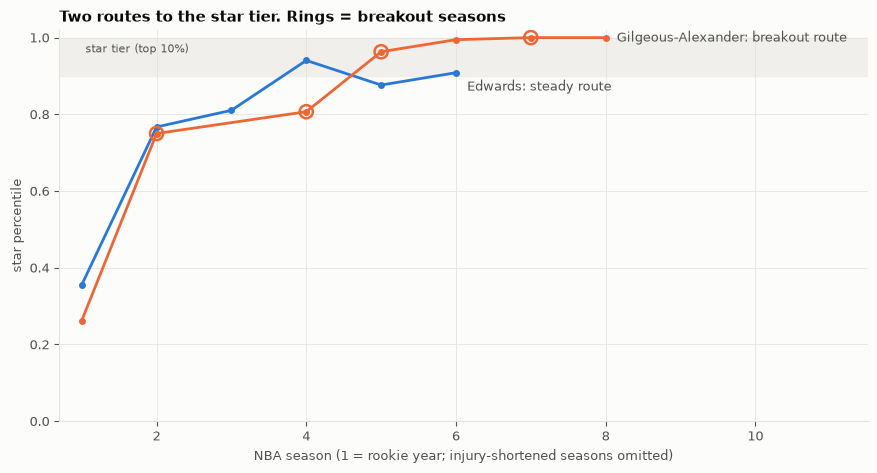

In [3]:
examples = {"Anthony Edwards": (SERIES[0], "Edwards: steady route"), "Shai Gilgeous-Alexander": (SERIES[1], "Gilgeous-Alexander: breakout route")}
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhspan(STAR_TIER_PCTL, 1.0, color="#f0efec", zorder=0)
ax.annotate("star tier (top 10%)", (1.05, 0.985), color=INK2, fontsize=8, va="top")
for name, (color, label) in examples.items():
    d = lab[(lab["player_name"] == name) & lab["star_pctl"].notna()]
    x = d["season_start"] - d["season_start"].min() + 1
    ax.plot(x, d["star_pctl"], color=color, marker="o", markersize=4, linewidth=2)
    brk = d[d["breakout_any"]]
    ax.scatter(brk["season_start"] - d["season_start"].min() + 1, brk["star_pctl"], s=90, facecolor="none",
               edgecolor=color, linewidth=1.8, zorder=4)
    ax.annotate(label, (x.iloc[-1], d["star_pctl"].iloc[-1]), xytext=(8, -10 if "Edwards" in name else 0), textcoords="offset points",
                va="center", color=INK2, fontsize=9)
ax.set_xlabel("NBA season (1 = rookie year; injury-shortened seasons omitted)"); ax.set_ylabel("star percentile")
ax.set_ylim(0, 1.02); ax.set_xlim(0.7, 11.5)
ax.set_title("Two routes to the star tier. Rings = breakout seasons", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "09_routes_examples.png", dpi=150, bbox_inches="tight")

### Is the steady route more predictable? (walk-forward backtest, predictions 2016-17 → 2022-23)

Same rules as notebook 06: a training row from season *s* is used only once its 3-season outcome is known (*s* + 3 ≤ *t*).

In [4]:
SMALL = ["age", "min_per_game_z", "usg_pct_z", "ts_pct_shr_z", "star_score", "usg_pct_z_delta", "min_per_game_z_delta",
         "pct_uast_fgm_z", "ast_pct_z", "fta_rate_z", "draft_pick_filled", "pie_z_delta"]

class SmallLogistic:
    def fit(self, X, y):
        self.m = logistic_model(C=1.0).fit(X[SMALL], y); return self
    def predict_proba(self, X):
        return self.m.predict_proba(X[SMALL])

FEATURES = feature_columns(lab)
MODELS = {"current star score": rule(lambda d: d["star_score"].fillna(-9)), "logistic (12)": SmallLogistic,
          "boosted trees": boosted_trees, "nearest comps": NearestComps}
population = (lab["age"] <= 25) & ~lab["star_tier"]
res = {}
for target in ["route_steady", "route_breakout", "star_tier_next3"]:
    P = walk_forward(lab, target, 3, population, 2016, 2022, MODELS, FEATURES)
    res[target] = bootstrap_ap(P, n_boot=500).join(evaluate(P)[["positives", "base_rate", "ROC_AUC", "precision@10", "recall@25"]])
table = pd.concat(res, names=["target", "model"])
table.round(3)

AP_lift  ci_low  ci_high  positives  \
target          model                                                     
route_steady    current star score    8.618   5.512   18.840         23   
                nearest comps         8.454   2.472   25.841         23   
                logistic (12)         6.627   4.763   11.164         23   
                boosted trees         4.580   2.959   12.936         23   
route_breakout  logistic (12)         5.551   3.692   10.469         29   
                boosted trees         4.791   2.547   12.109         29   
                current star score    4.611   3.585    7.518         29   
                nearest comps         2.949   2.063    5.074         29   
star_tier_next3 logistic (12)         8.525   6.355   13.599         62   
                current star score    7.666   5.998   11.196         62   
                nearest comps         7.060   4.947   11.258         62   
                boosted trees         6.604   4.957   10.146         62   

                                    base_rate  ROC_AUC  precision@10  \
target          model                                                  
route_steady    current star score      0.014    0.895         0.100   
                nearest comps           0.014    0.785         0.114   
                logistic (12)           0.014    0.909         0.043   
                boosted trees           0.014    0.820         0.086   
route_breakout  logistic (12)           0.018    0.886         0.143   
                boosted trees           0.018    0.799         0.100   
                current star score      0.018    0.876         0.071   
                nearest comps           0.018    0.785         0.043   
star_tier_next3 logistic (12)           0.038    0.931         0.314   
                current star score      0.038    0.911         0.300   
                nearest comps           0.038    0.886         0.271   
                boosted trees           0.038    0.885         0.286   

                                    recall@25  
target          model                          
route_steady    current star score      0.708  
                nearest comps           0.625  
                logistic (12)           0.694  
                boosted trees           0.514  
route_breakout  logistic (12)           0.493  
                boosted trees           0.350  
                current star score      0.524  
                nearest comps           0.405  
star_tier_next3 logistic (12)           0.788  
                current star score      0.662  
                nearest comps           0.703  
                boosted trees           0.594

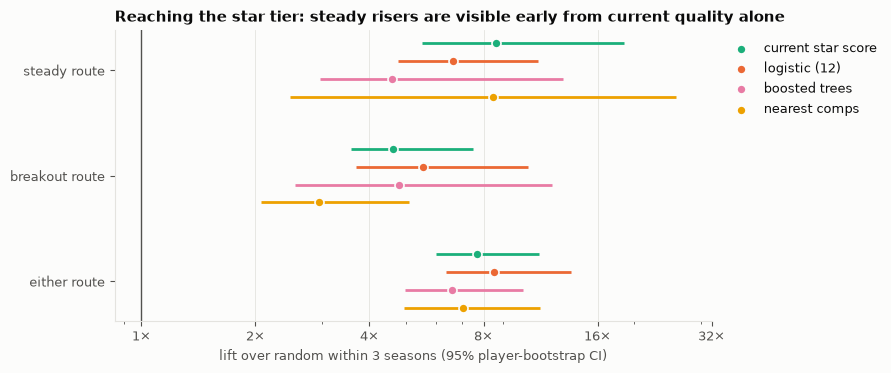

In [5]:
colors = {"current star score": SERIES[2], "logistic (12)": SERIES[1], "boosted trees": "#e87ba4", "nearest comps": SERIES[3]}
labels = {"route_steady": "steady route", "route_breakout": "breakout route", "star_tier_next3": "either route"}
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, (target, t) in enumerate(res.items()):
    for j, m in enumerate(MODELS):
        y = i + (j - 1.5) * 0.17
        ax.hlines(y, t.loc[m, "ci_low"], t.loc[m, "ci_high"], color=colors[m], linewidth=2)
        ax.scatter(t.loc[m, "AP_lift"], y, color=colors[m], s=42, edgecolor=SURFACE, linewidth=1.2, zorder=3,
                   label=m if i == 0 else None)
ax.axvline(1, color=INK2, linewidth=1)
ax.set_yticks(range(len(res)), [labels[t] for t in res]); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xscale("log"); ax.set_xticks([1, 2, 4, 8, 16, 32], ["1×", "2×", "4×", "8×", "16×", "32×"])
ax.set_xlabel("lift over random within 3 seasons (95% player-bootstrap CI)")
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_title("Reaching the star tier: steady risers are visible early from current quality alone", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "09_routes_predictability.png", dpi=150, bbox_inches="tight")

### Live: who is on a steady (or breakout) path to the star tier now?

In [6]:
NOW = 2025
cur = lab[(lab["season_start"] == NOW) & (lab["age"] <= 25) & ~lab["star_tier"]].copy()
train = lab[population & (lab["season_start"] + 3 <= NOW)]
for target in ["route_steady", "route_breakout", "star_tier_next3"]:
    cur[f"p_{target}"] = SmallLogistic().fit(train, train[target].astype(int)).predict_proba(cur)[:, 1]
cols = ["player_name", "age", "star_pctl", "star_score", "p_star_tier_next3", "p_route_steady", "p_route_breakout"]
display(cur.nlargest(15, "p_star_tier_next3")[cols].round(2).reset_index(drop=True))
print("Egor Dëmin:", cur.loc[cur["player_id"] == 1642856, cols[1:]].round(3).to_dict("records"))

,player_name,age,star_pctl,star_score,p_star_tier_next3,p_route_steady,p_route_breakout
0,Cooper Flagg,19.12,0.73,0.44,0.58,0.18,0.38
1,Stephon Castle,21.25,0.82,0.63,0.53,0.14,0.28
2,Alperen Sengun,23.52,0.87,0.68,0.43,0.10,0.13
3,Josh Giddey,23.31,0.82,0.59,0.37,0.06,0.16
4,Evan Mobley,24.62,0.89,0.71,0.36,0.11,0.08
5,Kon Knueppel,20.50,0.70,0.42,0.36,0.12,0.21
6,Walker Kessler,24.52,NaN,0.56,0.34,0.13,0.13
7,Paolo Banchero,23.22,0.71,0.42,0.32,0.09,0.09
8,VJ Edgecombe,20.51,0.57,0.28,0.32,0.08,0.22
9,Dylan Harper,19.92,0.62,0.33,0.29,0.08,0.15


Egor Dëmin: [{'age': 19.918, 'star_pctl': nan, 'star_score': -0.252, 'p_star_tier_next3': 0.031, 'p_route_steady': 0.009, 'p_route_breakout': 0.036}]


### Findings

- **Two genuinely different routes.** Of the young players who reached the star tier within 3 seasons:
  - **28 took the breakout route:** Shai, Giannis, Jokić, Tatum, Luka, Brunson, Haliburton, Cade, Maxey and others.
  - **19 took the steady route:** **Anthony Edwards**, Booker (from 2020-21), Donovan Mitchell, Kawhi, Paul George, Kyrie, Embiid, Fox, Mobley, Barnes, plus several steadily improving defensive bigs (Jordan, Capela, Allen, Claxton).
- **Steady risers really are predictable from where they stand.** The current star score alone gives **8.6× random** (CI 5.5–19) and catches 71% of steady risers in its top 25. No trained model beats it.
- **Breakout-route stars are harder to see coming:** 4.6× from current quality alone, 5.6× with the 12-signal model. They need trajectory signals (rising usage and minutes, self-creation).
- **Either route:** the 12-signal model reaches 8.5× (AUC 0.93); 31% of its top 10 reach the star tier within 3 seasons and 79% of eventual star-tier players are in its top 25.
- **Live (end of 2025-26), likeliest to reach the star tier by 2028-29:** Cooper Flagg (58%, leaning breakout route), Stephon Castle (53%), Alperen Şengün, Josh Giddey, Evan Mobley, Kon Knueppel. **Egor Dëmin: 3%**, about the base rate. One rookie season isn't enough to put him on either path yet.